In [67]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.model import SimpleTransformer
from src.mgf_dataset import simulate_ou_process

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [68]:
model = SimpleTransformer(**cfg['architecture'])
model_path = os.path.join('..', cfg['paths']['save_dir'], 'model_mgf.pth')

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    print(f"Loaded model from {model_path}")
else:
    print(f"Model not found at {model_path}")
    print("Run: python ../scripts/train.py")

NameError: name 'device' is not defined

In [56]:
cfg = load_full_config()
cfg

{'physics': {'theta': 0.15, 'mu': 0.0, 'sigma': 0.2, 'dt': 0.1, 'D': 0.02},
 'theta_sampling': {'distribution': 'lognormal', 'mean': 0.0, 'sigma': 2.0},
 'structure': {'total_time_steps': 1000,
  'num_trajectories': 10000,
  'sequence_length': 100},
 'target': {'order': 50},
 'training': {'train_split': 0.8, 'batch_size': 64},
 'paths': {'mgf_data_path': 'data/ou_mgf.pt',
  'save_dir': 'experiments',
  'mgf_model_name': 'model_mgf.pth'},
 'architecture': {'d_input': 1,
  'd_model': 64,
  'n_head': 4,
  'n_layers': 2,
  'max_len': 5000,
  'd_output': 50},
 'hyperparameters': {'batch_size': 64, 'learning_rate': 0.001, 'epochs': 5},
 'system': {'device': 'cpu'}}

In [57]:
trajectories, thetas, targets = create_mgf_dataset(cfg)
targets

Theta statistics: min=0.000, max=1798.889, mean=7.281


tensor([[[ 0.0000e+00,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 1.7855e-02,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 1.3929e-01,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [-3.3747e-02,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [-1.3005e-01,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [-2.3931e-01,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  3.9843e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 4.1002e-04,  3.9843e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 1.1961e-01,  3.9843e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 2.4373e-01,  3

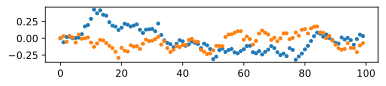

In [58]:

fig,ax = plt.subplots(figsize=(6,1))
ax.plot(trajectories[2,:,0].numpy(),".")
ax.plot(trajectories[300,:,0].numpy(),".")

In [59]:
trajectories[10,:,0].numpy()

array([ 0.        ,  0.00135312, -0.05395225, -0.02925621, -0.02199573,
        0.02913568,  0.00527103,  0.03734172,  0.05040502,  0.05231895,
       -0.00178212,  0.12867694,  0.17988068,  0.04990288,  0.07956813,
        0.13396691,  0.19809338,  0.1317462 ,  0.07469674,  0.1630356 ,
        0.1324423 ,  0.18584095,  0.24476397,  0.2971506 ,  0.25521356,
        0.10691369,  0.06807548,  0.06047167,  0.02181628, -0.05572513,
       -0.07396732, -0.07016528, -0.03829601, -0.12700683, -0.17307526,
       -0.0066634 ,  0.06849483,  0.0138337 ,  0.00799933, -0.00412779,
        0.01587968, -0.10304653,  0.01661761,  0.00665777,  0.02528118,
        0.04559159,  0.06284393,  0.0160848 ,  0.08373681,  0.07988486,
        0.10611992,  0.02743654,  0.02453957,  0.05688556,  0.06013832,
       -0.01615069, -0.09952463,  0.02207131,  0.08731759,  0.1225483 ,
        0.12002021,  0.04238417, -0.00792398, -0.10507882, -0.0502002 ,
       -0.00350965,  0.04824198,  0.14271389,  0.08780184,  0.02

In [60]:
thetas.unsqueeze(1)

tensor([[1.0683],
        [0.0394],
        [0.1026],
        ...,
        [9.0085],
        [3.3340],
        [1.2989]])

In [61]:
targets

tensor([[[ 0.0000e+00,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 1.7855e-02,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 1.3929e-01,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [-3.3747e-02,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [-1.3005e-01,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [-2.3931e-01,  3.6015e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  3.9843e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 4.1002e-04,  3.9843e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 1.1961e-01,  3.9843e-03,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 2.4373e-01,  3